### Task I : Data characterization

**Libraries**

In [1]:
# Import Libraries 
import pandas as pd 
import numpy as np
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

**Load the dataset**

In [2]:
# load csv file containing cdr for the two months sin milan
df_cdrs = pd.read_csv('internet_traffic_milano_nov-dec-2013.csv')
df_cdrs["Time Interval"] = pd.to_datetime(df_cdrs["Time Interval"], utc=True, unit='ms')

In [3]:
df_cdrs["Time Interval"].min(), df_cdrs["Time Interval"].max()

(Timestamp('2013-10-31 23:00:00+0000', tz='UTC'),
 Timestamp('2014-01-01 22:50:00+0000', tz='UTC'))

#### Q2. probability density function of the traffic in the target city in the target city

#### 

In [4]:
# 10,000 samples that each represent the total two-month traffic in one geographical area
data = df_cdrs.groupby(['Square id'])['Internet traffic activity'].sum().to_frame()
data.head()

,Internet traffic activity
Square id,
1,92992.666580
2,93368.388389
3,93768.329391
4,91904.381588
5,83630.697355


In [5]:
data['Internet traffic activity'].mean(), data['Internet traffic activity'].std()

(np.float64(555289.418737023), np.float64(892595.7321769565))

/tmp/ipykernel_3098306/1180208084.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.kdeplot(


<Axes: xlabel='Internet traffic activity', ylabel='Density'>

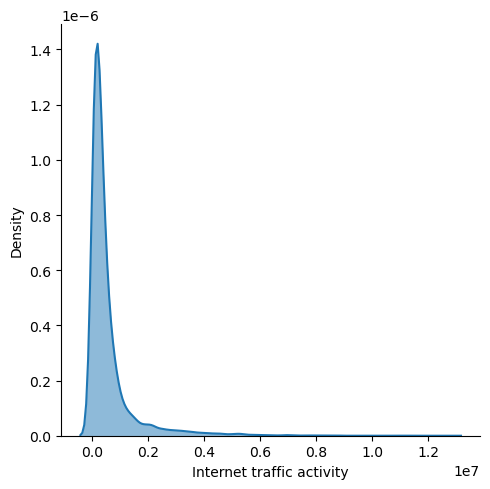

In [6]:
sns.displot(data, x='Internet traffic activity', kind = 'kde')
sns.kdeplot(
   data=data,x='Internet traffic activity',
   fill=True, common_norm=False, palette="crest",
   alpha=.5, linewidth=0,
)

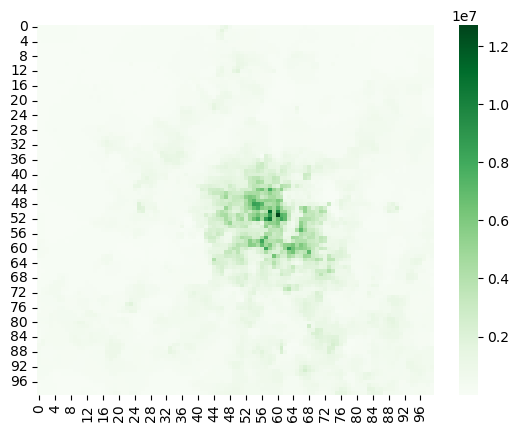

In [7]:

ax = sns.heatmap(data.to_numpy().reshape(100, 100), cmap="Greens")

plt.show()

#### Q4. time series of network traffic during the first two weeks at three areas

##### (i) The area with the highest total traffic during the two-month period

In [8]:
df_5161 = df_cdrs.loc[df_cdrs['Square id'] == 5161].groupby(['Time Interval', 'Square id'], as_index=False).sum()
df_5161 = df_5161.drop(columns=['Square id'])
df_5161 = df_5161.set_index(['Time Interval']).sort_index()
df_5161 = df_5161.loc['2013-10-31 23:00:00':'2013-11-14 23:00:00']
df_5161_hourly = df_5161.resample('60min')['Internet traffic activity'].sum()

##### (ii) The area with Square id 4159

The area with the highest total traffic during the two-month period

In [9]:
data[['Internet traffic activity']].idxmax()

Internet traffic activity    5161
dtype: int64

In [10]:
df_4159 = df_cdrs.loc[df_cdrs['Square id'] == 4159].groupby(['Time Interval', 'Square id'], as_index=False).sum()
df_4159 = df_4159.drop(columns=['Square id'])
df_4159 = df_4159.set_index(['Time Interval']).sort_index()
df_4159 = df_4159.loc['2013-10-31 23:00:00':'2013-11-14 23:00:00']
df_4159_hourly = df_4159.resample('60min')['Internet traffic activity'].sum()

##### (iii)The area with Square id 4556


In [11]:
df_4556 = df_cdrs.loc[df_cdrs['Square id'] == 4556].groupby(['Time Interval', 'Square id'], as_index=False).sum()
df_4556 = df_4556.drop(columns=['Square id'])
df_4556 = df_4556.set_index(['Time Interval']).sort_index()
df_4556 = df_4556.loc['2013-10-31 23:00:00':'2013-11-14 23:00:00']
df_4556_hourly = df_4556.resample('60min')['Internet traffic activity'].sum()

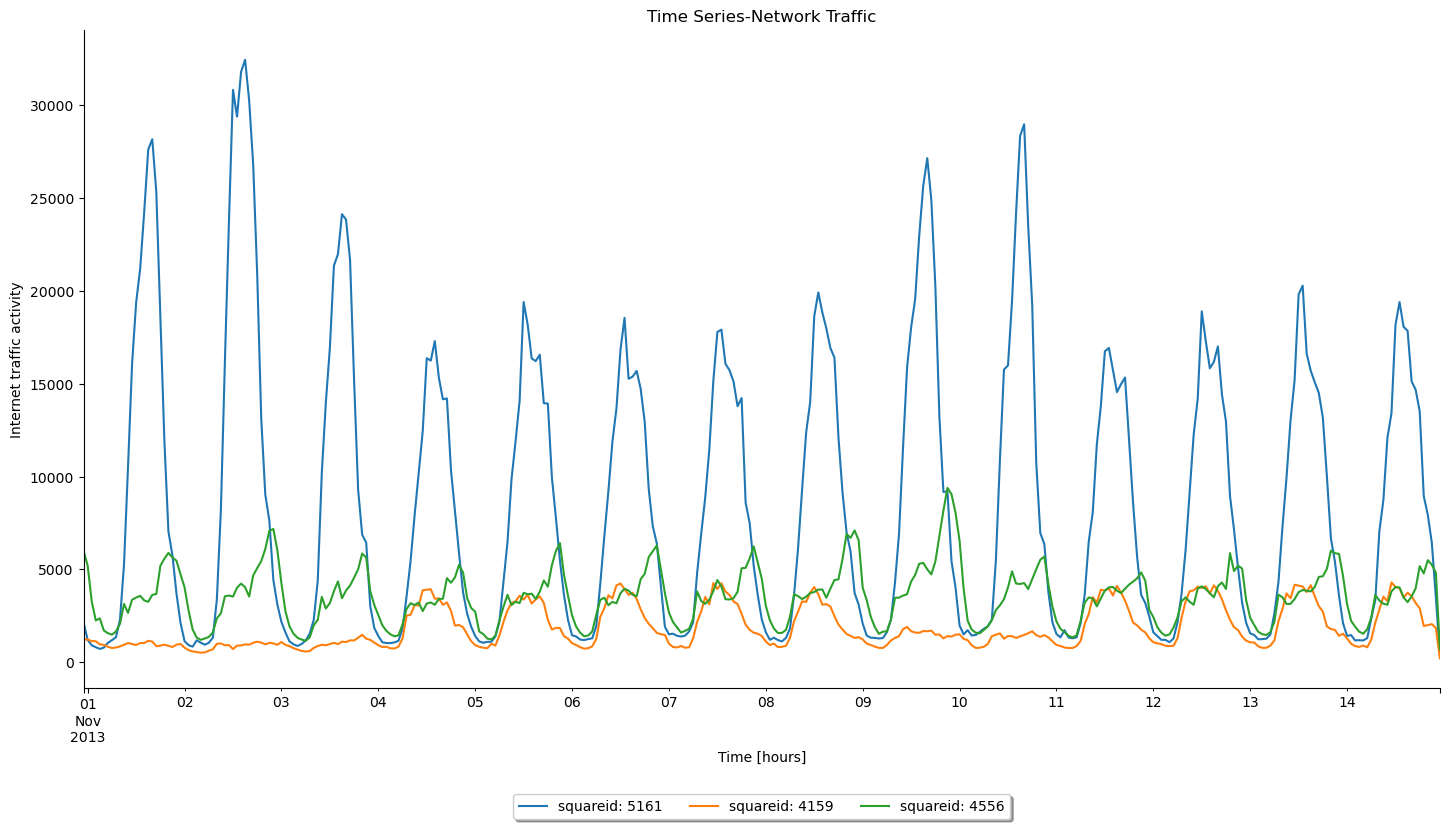

In [12]:
f = plt.figure()

ax = df_5161_hourly.plot(label='squareid: 5161')
df_4159_hourly.plot(ax=ax, label='squareid: 4159')
df_4556_hourly.plot(ax=ax, label='squareid: 4556')


plt.xlabel("Time [hours]")
plt.ylabel("Internet traffic activity")
sns.despine()
plt.title('Time Series-Network Traffic') 
# Shrink current axis's height by 10% on the bottom
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=5)

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(17.5, 9.5, forward=True)

In [13]:
df_5161_daiy = df_5161.resample('D')['Internet traffic activity'].sum()
df_4556_daily = df_4556.resample('D')['Internet traffic activity'].sum()
df_4159_daily = df_4159.resample('D')['Internet traffic activity'].sum()

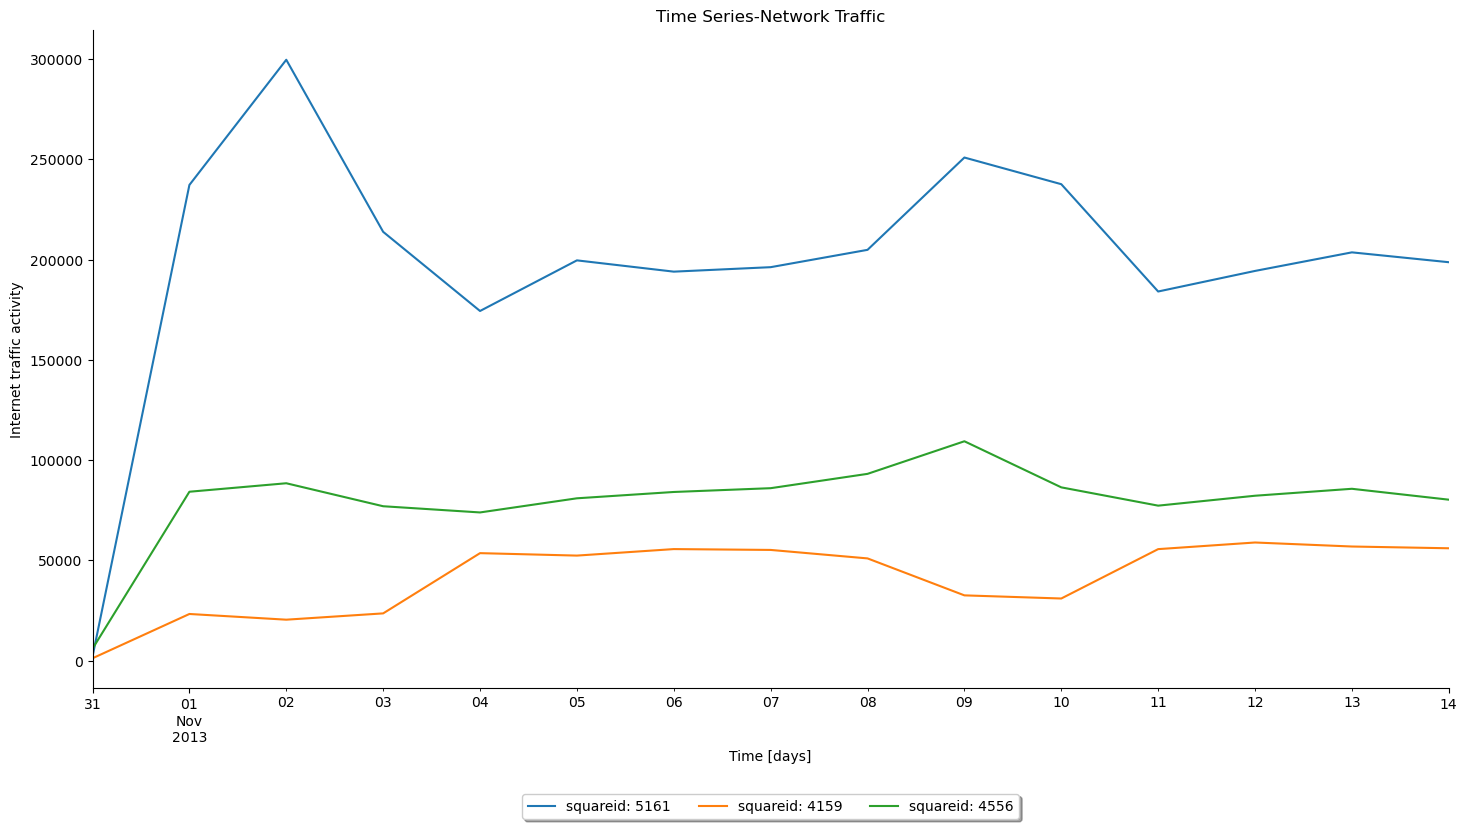

In [14]:
f = plt.figure()

ax = df_5161_daiy.plot(label='squareid: 5161')
df_4159_daily .plot(ax=ax, label='squareid: 4159')
df_4556_daily.plot(ax=ax, label='squareid: 4556')

plt.xlabel("Time [days]")
plt.ylabel("Internet traffic activity")
sns.despine()
plt.title('Time Series-Network Traffic') 
# Shrink current axis's height by 10% on the bottom
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=5)

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(17.5, 9.5, forward=True)

**Average hourly internet traffic over the fisrt two weeks**

In [15]:
df_5161 = df_5161.reset_index()
df_4159 = df_4159.reset_index()
df_4556 = df_4556.reset_index()

In [16]:
df_5161_avg_day = df_5161.groupby(df_5161["Time Interval"].dt.hour)["Internet traffic activity"].mean()
df_4159_avg_day = df_4159.groupby(df_4159["Time Interval"].dt.hour)["Internet traffic activity"].mean()
df_4556_avg_day = df_4556.groupby(df_4556["Time Interval"].dt.hour)["Internet traffic activity"].mean()

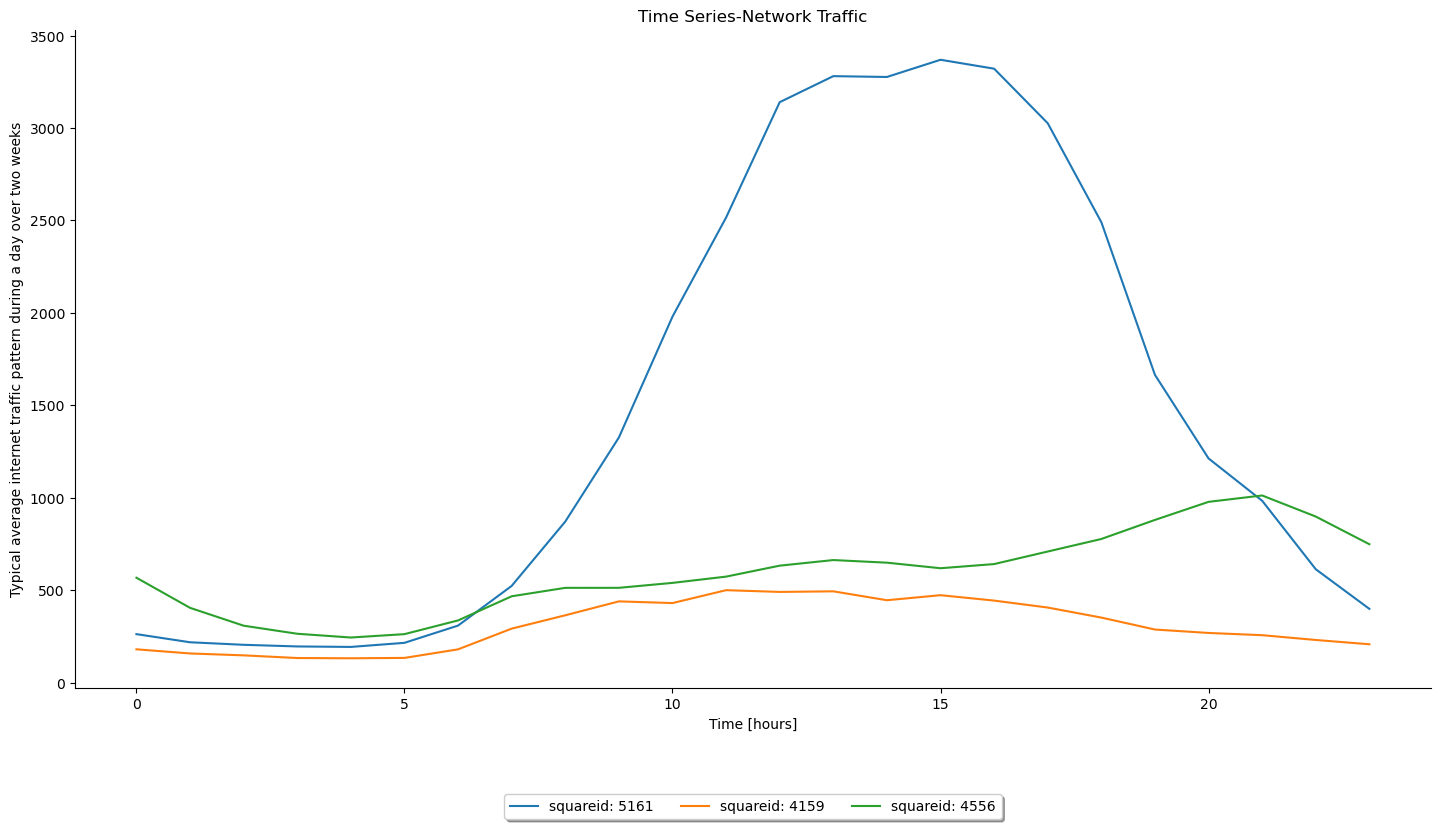

In [17]:
f = plt.figure()

ax = df_5161_avg_day.plot(label='squareid: 5161')
df_4159_avg_day.plot(ax=ax, label='squareid: 4159')
df_4556_avg_day.plot(ax=ax, label='squareid: 4556')


plt.xlabel("Time [hours]")
plt.ylabel("Typical average internet traffic pattern during a day over two weeks")
sns.despine()
plt.title('Time Series-Network Traffic') 
# Shrink current axis's height by 10% on the bottom
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          fancybox=True, shadow=True, ncol=5)

fig = matplotlib.pyplot.gcf()
fig.set_size_inches(17.5, 9.5, forward=True)